# Ajustement de cercles et d'Ellipses

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy.optimize import least_squares

### Méthode 2 — Ajustement non linéaire par moindres carrés géométriques

On note
$
\theta=(x_c,y_c,r)\in\mathbb{R}^2\times\mathbb{R}_+.
$

La fonction à minimiser est :
$
F(\theta) =\sum_{i=1}^n\left(\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r\right)^2
=\sum_{i=1}^n \rho_i(\theta)^2
$

en notant
$
\rho_i(\theta)=\sqrt{(x_i-x_c)^2+(y_i-y_c)^2}-r
$ , le résidu géométrique

---
### Existence d’un minimiseur

La fonction $F$ est continue sur $\mathbb{R}^2\times\mathbb{R}_+$.

- A $(x_c,y_c)$ fixé, la fonction $r\mapsto F(x_c,y_c,r)$ est convexe et son gradient s'annule, elle admet donc un minimum.
- A $r$ fixé, $(x_c,y_c)\mapsto F(x_c,y_c,r)$ est infini à l'infini, donc elle admet au moins un minimimum.

F admet donc au moins un minimiseur $\theta^*$

---

### Formulation vectorielle

On introduit le vecteur des résidus

$
\rho(\theta)=
\begin{pmatrix}
\rho_1(\theta)\\
\vdots\\
\rho_n(\theta)
\end{pmatrix}
\in\mathbb{R}^n
$

On a alors $F(\theta)=\|\rho(\theta)\|_2^2$


### Aproximation du minimiseur par la methode de Gausse-Newton

On construit une suite $(\theta_n)_{n\ge0}$ convergent vert $\theta^*$.


Soit $n \in \mathbb{N}$ et $\theta_n > 0$ la fonction $\rho$ étant $\mathcal C^1$, pour tout $h$ on a:

$$\rho(\theta_n+h)=\rho(\theta_n)+J(\theta_n)h+o(\|h\|)$$

où $J(\theta_n)\in\mathbb{R}^{n\times3}$ est la jacobienne de $\rho$ en $\theta_n$.

Ainsi $$F(\theta_n+h)\approx\|\rho(\theta_n)+J(\theta_n)h\|^2$$

D'après la formule de l'estimateur des moindres carrées obtenu par annulation du gradient, Si $J(\theta_n)^T J(\theta_n)$ est inversible, cette quantité est minimisée par :

$$h^*= -(J(\theta_n)^T J(\theta_n))^{-1}J(\theta_n)^T\rho(\theta_n)$$

on note alors $h^*:=h_n$ et $\theta_{n+1}=\theta_n+h_n$

et par definition d'un minimiseur, 

$$F(\theta_{n+1})=F(\theta_n+h_n)<F(\theta_n + 0)$$

Donc la suite ainsi défini converge bien vers le minimiseur.


---

### Méthode de Levenberg–Marquardt

Afin d’améliorer la stabilité numérique, on considère la minimisation régularisée

$\min_h\|\rho(\theta_n)+J(\theta_n)h\|^2+\lambda_n\|h\|^2,\qquad \lambda_n>0$

En calculant le zéro du gradient on trouve que le minimiseur $h^*$ vérifie cette fois:

$$h^*=-(J(\theta_n)^T J(\theta_n)+\lambda_n I)^{-1}J(\theta_n)^T\rho(\theta_n)$$

Ou $J(\theta_n)^T J(\theta_n)+\lambda_n I$ est définie positive pour $\lambda_n>0$, ce qui garantit l’inversibilité du système.

Et on définit de la même façon $\theta_{n+1}=\theta_n+h_n$

La méthode de Levenberg–Marquardt concilie deux methodes :

- La descente de gradient pour $\lambda_n$ grand
- la méthode de Gauss–Newton pour $\lambda_n$ petit

Elle offre ainsi une meilleure robustesse loin du minimum tout en conservant une convergence rapide au voisinage de la solution.

---
### implémentation

Le code ci-dessous implémente la méthode 2 pour calculer $\theta^*$ à partir d'un jeu de donnée. 

In [ ]:
#minimisation sans contrainte
def methode2(x, y, method='lm',max_nfev=1000):
    '''
    (x,y): données
    method: par défaut methode Levenberg-Marquardt avec régularisation
    ----
    minimisation sans contraintes
    précision?
    '''
    #definition de la fonction des residus
    def residus(theta):
        xc, yc, r = theta
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)
    r0  = np.mean(np.sqrt((x-xc0)**2 + (y-yc0)**2))

    result = least_squares(residus, x0=(xc0, yc0, r0), method=method, max_nfev=max_nfev)  #max nombre d'itération1000
    #voir vitesse de convergence et critère d'arret
    
    return result.x
#LM est une version améliorée de la methode de Gausse-Newton, étudier la convergence de la suite des paramêtres

---

### Méthode 3 — Ajustement non linéaire par moindres carrés géométriques avec contrainte

On ajoute à la methode 2 la contrainte suivante: le point $(x_n,y_n)$ appartient au cercle. Le rayon est alors entièrement déterminé par ce point et les paramêtres $(x_c,y_c)$.
$$r=\sqrt{(x_n-x_c)^2 + (y_n -y_c)^2}$$

In [ ]:
def methode3(x,y, method='lm',max_nfev=1000):
    '''
    minimisation avec contrainte
    Datas (x,y)
    par défaut methode Levenberg-Marquardt avec régularisation
    '''

    #definition avec contrainte
    def residus(theta):
        xc, yc = theta #2 paramêtres car r dépend de xc et yc
        r = np.mean(np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2))
        return np.sqrt((x-xc)**2 + (y-yc)**2) - r
    
    # initialisation
    xc0 = np.mean(x)
    yc0 = np.mean(y)

    result = least_squares(residus, x0=(xc0, yc0), method=method, max_nfev=max_nfev)  #max nombre d'itération 1000
    
    xc,yc = result.x
    r=np.sqrt((x[-1]-xc)**2 + (y[-1]-yc)**2)

    return xc,yc,r

---

### Test sur un jeu de données créé

In [21]:
random.seed()

#création d'un jeu de données de test

n=300 #nombre de points

# selection de points issus du vrai cercle
r=3 #rayon du vrai cercle
theta = np.random.uniform(0, 2*np.pi, n) 
x = r * np.cos(theta) 
y = r * np.sin(theta)

#bruitage des points
sigma=0.5
bruit = np.random.normal(loc=0, scale=np.sqrt(sigma), size=(n, 2))
x_bruite = x + bruit[:,0]
y_bruite = y + bruit[:,1]

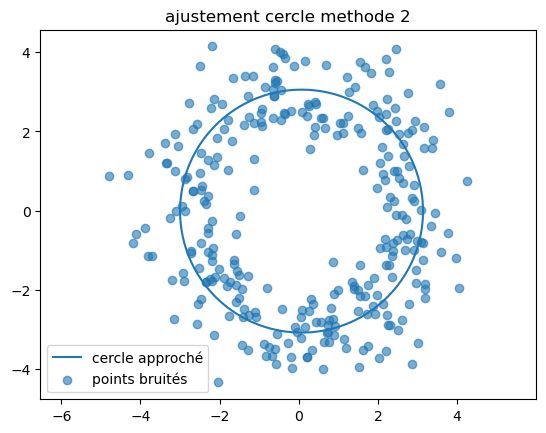

In [88]:
#visualisation methode 2

xc, yc, r =methode2(x_bruite,y_bruite)
theta = np.linspace(0, 2*np.pi, 300)
x_cercle = xc + r*np.cos(theta)
y_cercle = yc + r*np.sin(theta)
plt.plot(x_cercle, y_cercle, label="cercle approché")
plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

plt.axis("equal")
plt.title("ajustement cercle methode 2")
plt.legend()
plt.show()


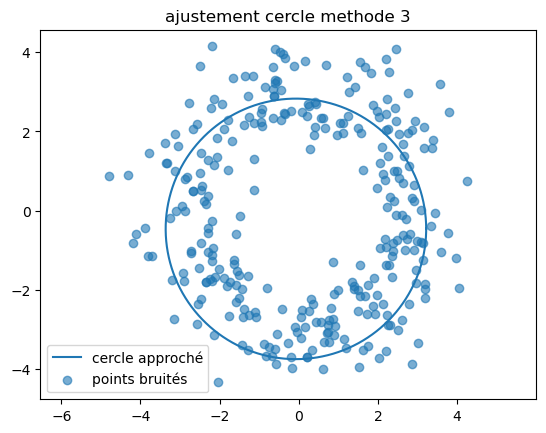

In [87]:
#visulaisation methode 3

xc, yc, r =methode3(x_bruite,y_bruite)
theta = np.linspace(0, 2*np.pi, 300)
x_cercle = xc + r*np.cos(theta)
y_cercle = yc + r*np.sin(theta)
plt.plot(x_cercle, y_cercle, label="cercle approché")
plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

plt.axis("equal")
plt.title("ajustement cercle methode 3")
plt.legend()
plt.show()

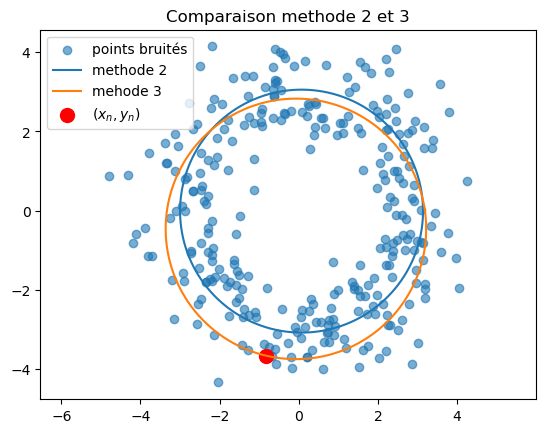

In [85]:
#superposition

plt.scatter(x_bruite, y_bruite, alpha=0.6, label="points bruités")

xc2, yc2, r2 =methode2(x_bruite,y_bruite)
xc3, yc3, r3 =methode3(x_bruite,y_bruite)

theta = np.linspace(0, 2*np.pi, 300)

x_cercle2 = xc2 + r2*np.cos(theta)
y_cercle2 = yc2 + r2*np.sin(theta)
plt.plot(x_cercle2, y_cercle2, label="methode 2 ")

x_cercle3 = xc3 + r3*np.cos(theta)
y_cercle3 = yc3 + r3*np.sin(theta)
plt.plot(x_cercle3, y_cercle3, label="mehode 3")

plt.scatter(x_bruite[-1], y_bruite[-1], color='red', s=100, label=r'$(x_n,y_n)$')

plt.axis("equal")
plt.title("Comparaison methode 2 et 3")
plt.legend()
plt.show()

La methode 3 donne de l'importance au point $(x_n,y_n)$ sans faire de distinction entre une valeur extrème ou proche de la moyenne. La methode 3 est donc une moins bonne approximation de la majorité des points.

### Test sur le jeu de donnée 1

In [81]:
data=pd.read_csv("data1.txt", header=None, sep=" ")

X=data[0].tolist()
Y=data[1].tolist()

###data2=data.drop()

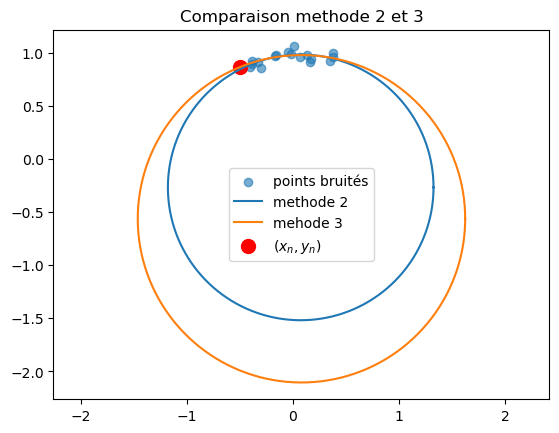

In [90]:
plt.scatter(X, Y, alpha=0.6, label="points bruités")

xc2, yc2, r2 =methode2(X,Y)
xc3, yc3, r3 =methode3(X,Y)

theta = np.linspace(0, 2*np.pi, 300)

x_cercle2 = xc2 + r2*np.cos(theta)
y_cercle2 = yc2 + r2*np.sin(theta)
plt.plot(x_cercle2, y_cercle2, label="methode 2 ")

x_cercle3 = xc3 + r3*np.cos(theta)
y_cercle3 = yc3 + r3*np.sin(theta)
plt.plot(x_cercle3, y_cercle3, label="mehode 3")

plt.scatter(X[-1], Y[-1], color='red', s=100, label=r'$(x_n,y_n)$')

plt.axis("equal")
plt.title("Comparaison methode 2 et 3")
plt.legend()
plt.show()

## Comparaison methode 1 et 2

... (à faire par Marya) 

methode 1 = rapide

methode 2= plus précise mais couteuse

## Méthode proposée pour l'ellipse

D'après la comparaison ci-dessus et les résultats de l'article de ..., nous proposons un ajustement géométrique par Gauss–Newton avec une initialisation algébrique. En effet cette methode permettra de combiner la rapidité et faible cout computationnelle de la méthode linéaire avec la précision de la methode non linéaire.

### 1. Initialisation algébrique

L'équation générale d'une ellipse est de la forme:

$$
ax^2 + bxy + by^2 + dx + ey + f = 0.
$$

L'article utilise l'écriture matricielle suivante:
$$
z^\top A z + B^\top z + f = 0,
$$

où

$$
z =
\begin{pmatrix}
x\\y
\end{pmatrix},
\qquad
A =
\begin{pmatrix}
a & b/2\\
b/2 & c
\end{pmatrix},
\qquad
B =
\begin{pmatrix}
d\\e
\end{pmatrix},
\qquad
$$

Notons $X$ la matrice contenant les données telles que les lignes correspondent au $n$ observtions. l'équation s'écrit alors

$$
X u=0,
$$

où

$$
u=(A_{11},\,2A_{12},\,A_{22},\,B_1,\,B_2,\,f)^\top= (a,b,c,d,e,f)
$$

Nous allons determiner le paramêtre $u^*$ de l'ellipse qui ajuste le mieux nos données par moindre carré linéaire de la methode 1.


Comme ce système homogène admet toujours la solution triviale \(u=0\), il faut imposer une contrainte. D'après l'article, La contrainte standard $\|u\|=1$ n'est pas satisfaisante, car elle n'est pas invariante par rotatation et translation du repère. Pour cette raison, on utilise la contrainte de Bookstein.

$$\lambda_1^2+\lambda_2^2 = A_{11}^2 + 2A_{12}^2 + A_{22}^2 = 1$$

où $\lambda_1,\lambda_2$ sont les valeurs propres de la matrice $A$



### 2. Calcul des demies axes, centre et inclinaison de l'ellipse initiale

Notons à présent $u*=(A_{11},\,2A_{12},\,A_{22},\,B_1,\,B_2,\,f)^\top$ les solutions de la méthode linéaire. 

$A\in\mathbb{R}^{2\times 2}$ est une matrice symétrique, dans le cas d’une ellipse, elle est aussi définie positive d'après l'article. Elle est donc diagonalisable dans une base orthornormée est on écrit $A=Q^\top \widetilde{A} Q$ où $Q$ est ortogonale et $\widetilde{A}= diag(\lambda_1, \lambda_2)$. 

On effectue ensuite le changement de repère:

$$
z = Q\tilde{z} + t,
$$

de sorte que l'équation s'écrivent

$$
\tilde{z}^\top \widetilde{A}\tilde{z}+\widetilde{b}^\top \tilde{z}+\widetilde{c}=0.
$$

puis on choisi $t_0$ tel que $\widetilde{b}=0$, l'équation devient alors:




$$
\frac{\tilde{x}^2}{-\widetilde{c}/\lambda_1}
+
\frac{\tilde{y}^2}{-\widetilde{c}/\lambda_2}
=1.
$$

On lit alors immédiatement les demi-axes :

$$
v_1^{(0)}=\sqrt{\frac{-\widetilde{c}}{\lambda_1}},
\qquad
v_2^{(0)}=\sqrt{\frac{-\widetilde{c}}{\lambda_2}}.
$$

Le centre de l’ellipse dans le repère initial est donné par le vecteur de translation $t_0$.

l’orientation de l’ellipse est donnée par la matrice de rotation $Q$. 


### 3. Itération de Gauss-Newton

Notons $z_i=(x_i,y_i)\in\mathbb{R}^2$, pour $i=1,\dots,m$, les points observés. Pour chaque point $z_i$, on introduit un paramètre $\varphi_i$ localisant le point correspondant sur l’ellipse.

L’ellipse peut être décrite sous forme paramétrique :

$$
\gamma(\varphi):=
t+P(\alpha)
\begin{pmatrix}
v_1\cos\varphi\\
v_2\sin\varphi
\end{pmatrix},
$$

où

$$t=(t_1,t_2)\in\mathbb{R}^2,\qquad v_1,v_2>0$$
et $P(\alpha) $ une matrice de rotation d'angle $\alpha$

on cherche donc $u=(\varphi_1,\dots,\varphi_m,v_1,v_2,t_1,t_2,\alpha)$ qui minimise $\sum_{i=1}^m \left\| P_i-\gamma(\varphi_i)\right\|^2$

On obtient ainsi un problème de moindres carrés non linéaires  
$$
\min_u \sum_{i=1}^m \|g_i(u)\|^2.
$$

en notant les résidus $g_i(u)=z_i-\gamma(\varphi_i)$

Comme pour la méthode 2 on construit une suite $(u_n)$ convergent vers $u^*$ tel que $u_0=(\varphi_1^{(0)},\dots,\varphi_m^{(0)},v_1^{(0)},v_2^{(0)},t_1^{(0)},t_2^{(0)},\alpha_0)$ en notant $t_0=(t_1^{(0)},t_2^{(0)})$ et $\alpha_0$ l'angle de rotation de $Q$ tel que :

$$
Q=
\begin{pmatrix}
\cos\alpha_0 & -\sin\alpha_0\\
\sin\alpha_0 & \cos\alpha_0
\end{pmatrix},
$$

Enfin on itère jusqu'a atteindre une précision suffisante.

